In [1]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import torch
import seisbench.models as sbm
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from obspy import Stream
from glob import glob
import datetime

In [2]:
import sys
lib_path = [r'C:\Users\ikahbasi\OneDrive\Applications\GitHub\SeisRoutine',
            r'C:\Users\ikahb\OneDrive\Applications\GitHub\SeisRoutine',
            '/home/ikahbasi/Works/SeisRoutine/']
for path in lib_path:
    sys.path.append(path)
##########################################################################
import SeisRoutine.plot as srp
import SeisRoutine.catalog as src
import SeisRoutine.config as srconf

In [3]:
# logging.getLogger().setLevel(logging.INFO)
# srconf.configure_logging(level='info', mode='file', filename='now')

In [4]:
from glob import glob
from tqdm import tqdm

In [5]:
lst_df_ev = []

outpath = '/home/ikahbasi/Documents/Results'
for fpath in tqdm(glob(f'{outpath}/*.pkl')):
    df_ev = pd.read_pickle(fpath)
    lst_df_ev.append(df_ev)
df_cat = pd.concat(lst_df_ev, axis=0)

  0%|          | 0/9187 [00:00<?, ?it/s]

100%|██████████| 9187/9187 [00:07<00:00, 1152.09it/s]


In [6]:
lst = []
for key, val in df_cat['catalog_picktime'].items():
    # print(key, val)
    if isinstance(val, np.ndarray):
        if len(val) == 1:
            lst.append(val[0])
        else:
            if key.endswith('_P'):
                lst.append(min(val))
            elif key.endswith('_S'):
                lst.append(np.mean(val))
    elif np.isnan(val):
        lst.append(np.nan)
    else:
        raise ValueError
df_cat['catalog_picktime'] = lst

In [7]:
lst = []
for key, val in df_cat['catalog_pickdist'].items():
    # print(key, val)
    if isinstance(val, np.ndarray):
        if len(val) == 1:
            lst.append(val[0])
        else:
            if key.endswith('_P'):
                lst.append(min(val))
            elif key.endswith('_S'):
                lst.append(np.mean(val))
    elif np.isnan(val):
        lst.append(np.nan)
    else:
        raise ValueError
df_cat['catalog_pickdist'] = lst

In [8]:
keys = [key for key in df_cat.keys() if key.endswith('_picktime')]
diff = df_cat[keys].apply(lambda x: x-x['catalog_picktime'], axis=1)
diff['catalog_pickdist'] = df_cat['catalog_pickdist']

In [ ]:
# df_cat[keys].apply(lambda x: x-x['catalog_picktime'])#  - df_cat['catalog_picktime'].values
# # df_cat['catalog_picktime'] - df_cat['catalog_picktime']

In [ ]:
# keys = [key for key in df_cat.keys() if key.endswith('_picktime')]
# df_selected = df_cat[keys] - df_cat['catalog_picktime']
# df_selected

In [ ]:
# keys = [key for key in df_cat.keys() if key.endswith('_picktime')]
# df_selected = df_cat[keys]
# diff = df_selected['PhaseNet_original_picktime'] - df_selected['catalog_picktime']
# np.concat(diff.values)

In [ ]:
# srp.histogram(arr2, orientation='vertical', figsize=(6, 4))
# srp.histogram(arr2, orientation='vertical', figsize=(6, 4), title=f'{key}  {phase}')

In [ ]:
# non_empty_arrays = [arr for arr in filtered[key].values if isinstance(arr, np.ndarray) and arr.size > 0]
# non_empty_arrays

In [ ]:
# [arr for arr in filtered['catalog_pickdist'].values if isinstance(arr, np.ndarray) and arr.size > 0]

In [9]:
def filter_min_residual(row, key):
    el = row[key]
    if isinstance(el, np.ndarray):
        if all(np.isnan(el)):
            output = np.nan
        else:
            output = el[np.argmin(np.abs(el))]
    else:
        if np.isnan(el):
            output = np.nan

    return output

# diff_filtered.apply(lambda x: filter_min_residual(row=x, key=key), axis=1)

_P


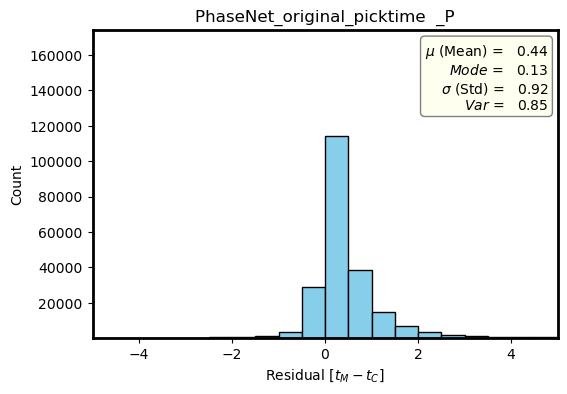

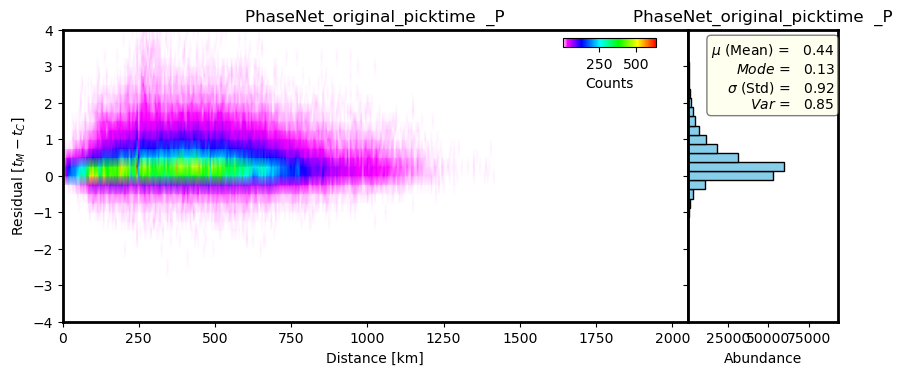

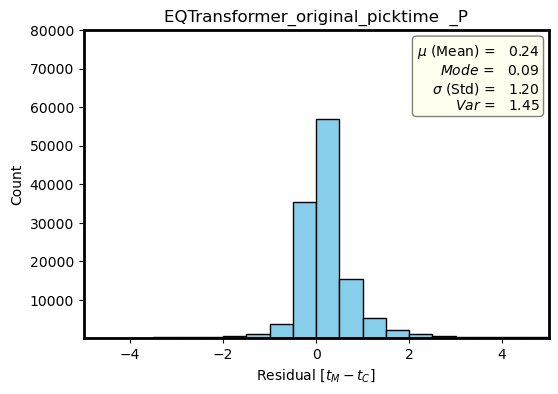

_S


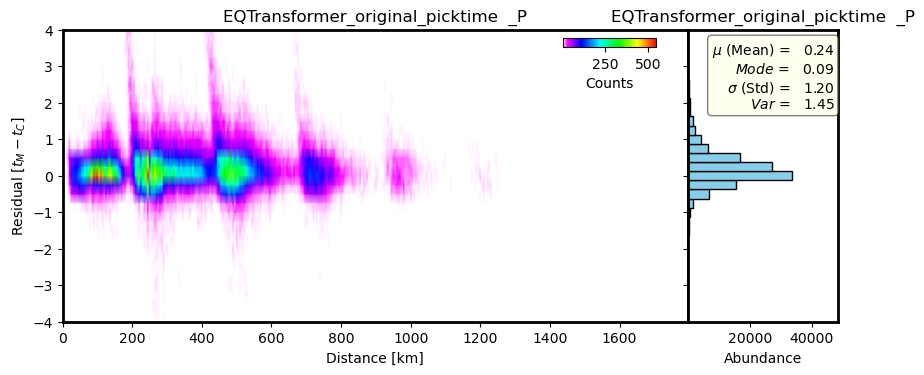

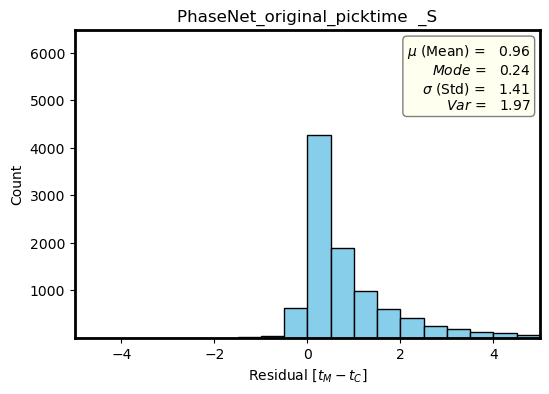

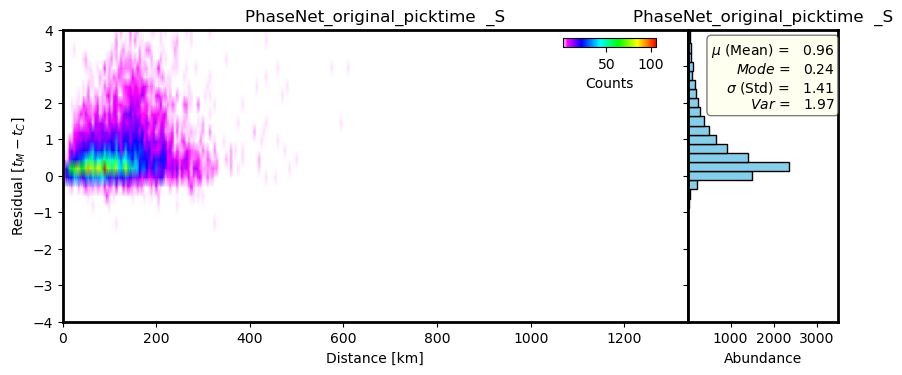

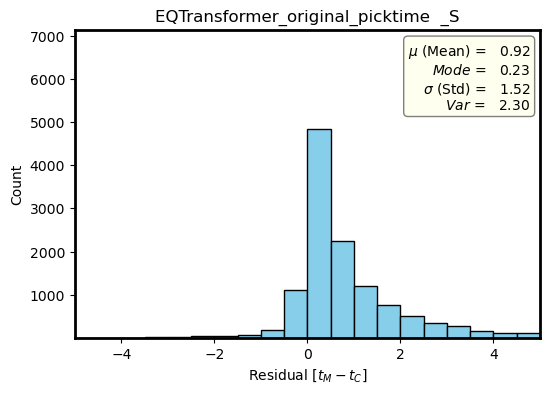

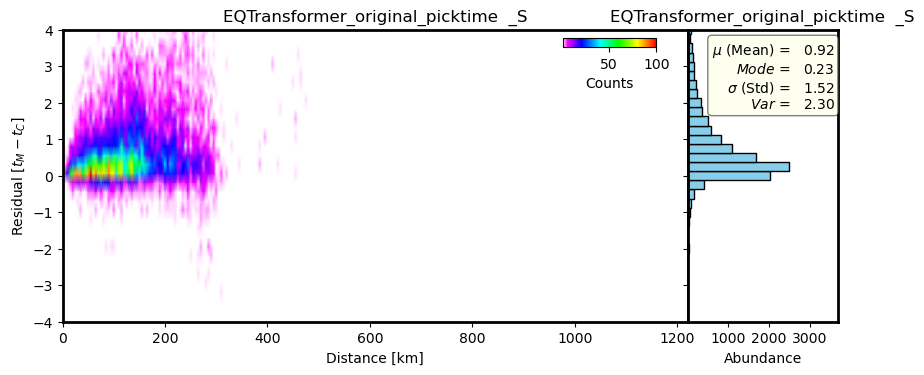

In [13]:
diff['id'] = diff.index
diff.reset_index(drop=True)
keys = diff.keys().tolist()
keys.remove('catalog_picktime')
keys.remove('catalog_pickdist')
keys.remove('id')

# diff_filtered = diff[diff['catalog_picktime'].notna()]
for phase in ['_P', '_S']:
    diff_filtered = diff[diff['id'].str.endswith(phase)].copy()
    print(phase)
    # print(filtered)
    for key in keys:
        diff_filtered[key] = diff_filtered.apply(lambda x: filter_min_residual(row=x, key=key), axis=1)
        # diff_filtered2 = diff_filtered.explode(key)
        diff_filtered2 = diff_filtered[diff_filtered[key].notna()]

        # diff_filtered2[key, 'catalog_pickdist']
        arr_error = diff_filtered2[key].values
        arr_dist = diff_filtered2['catalog_pickdist'].values
        msk = np.abs(arr_error) <= 10
        arr_error = arr_error[msk].tolist()
        arr_dist = arr_dist[msk].tolist()
        #
        # arr_dist = filtered['catalog_pickdist'][msk].values
        srp.histogram(arr_error,
                      orientation='vertical',
                      figsize=(6, 4), title=f'{key}  {phase}', around_zero=False, step=0.5,
                      xlim=[-5, 5],
                      xlabel='Residual [$t_M - t_C$]', ylabel='Count',
                      save=True, savefile=f'{key}{phase}_hist.png')
        srp.density_hist(x=arr_dist, y=arr_error,
                         xstep=5, ystep=0.25,
                         ylim=[-4, 4],
                         figsize=(10, 4), title=f'{key}  {phase}',
                         xlabel='Distance [km]', ylabel='Residual [$t_M - t_C$]',
                         save=True, savefile=f'{key}{phase}_dist.png')

In [ ]:
diff['id'] = diff.index
diff.reset_index(drop=True)
keys = diff.keys().tolist()
keys.remove('catalog_picktime')
keys.remove('catalog_pickdist')
keys.remove('id')

# diff_filtered = diff[diff['catalog_picktime'].notna()]
for phase in ['_P', '_S']:
    diff_filtered = diff[diff['id'].str.endswith(phase)].copy()
    print(phase)
    # print(filtered)
    for key in keys:
        diff_filtered2 = diff_filtered.explode(key)
        diff_filtered2 = diff_filtered2[diff_filtered2[key].notna()]

        # diff_filtered2[key, 'catalog_pickdist']
        arr_error = diff_filtered2[key].values
        arr_dist = diff_filtered2['catalog_pickdist'].values
        msk = np.abs(arr_error) <= 10
        arr_error = arr_error[msk].tolist()
        arr_dist = arr_dist[msk].tolist()
        #
        # arr_dist = filtered['catalog_pickdist'][msk].values
        srp.histogram(arr_error,
                      orientation='vertical',
                      figsize=(6, 4), title=f'{key}  {phase}', around_zero=False, step=0.5,
                      xlabel='Residual [$t_M - t_C$]', ylabel='Count',
                      save=True, savefile=f'{key}{phase}_hist.png')
        srp.density_hist(x=arr_dist, y=arr_error,
                         xstep=5, ystep=0.25,
                         ylim=[-4, 4],
                         figsize=(10, 4), title=f'{key}  {phase}',
                         xlabel='Distance [km]', ylabel='Residual [$t_M - t_C$]',
                         save=True, savefile=f'{key}{phase}_dist.png')

In [10]:
def extract_first_element(x):
    if isinstance(x, list):
        return x[0] if len(x) > 0 else np.nan
    elif isinstance(x, np.ndarray):
        return x[0] if x.size > 0 else np.nan
    else:
        return x

In [ ]:
for col in keys:
    df_cat[col] = df_cat[col].apply(extract_first_element)

In [ ]:
df_cat.count()

In [ ]:
for col in keys:
    mask = df_cat['catalog_picktime'].notna() & df_cat[col].isna()
    count = mask.sum()
    print(f"catalog [Detected], {col} [Not Detected] {count}")
    ##
    mask = df_cat['catalog_picktime'].isna() & df_cat[col].notna()
    count = mask.sum()
    print(f"catalog [Not Detected], {col} [Detected] {count}")
    ##
    mask = df_cat['catalog_picktime'].notna() & df_cat[col].notna()
    df_cat
    count = mask.sum()
    print(f"catalog [Detected], {col} [Detected] {count}")
    ##
    target = df_cat[mask]
    

catalog [Detected], PhaseNet_original_picktime [Not Detected] 44778
catalog [Not Detected], PhaseNet_original_picktime [Detected] 368281
catalog [Detected], PhaseNet_original_picktime [Detected] 242193
catalog [Detected], EQTransformer_original_picktime [Not Detected] 126362
catalog [Not Detected], EQTransformer_original_picktime [Detected] 244116
catalog [Detected], EQTransformer_original_picktime [Detected] 160609


In [18]:
for col in keys:
    mask = df_cat['catalog_picktime'].notna() & df_cat[col].notna()
    count = mask.sum()
    print(f"catalog [Detected], {col} [Detected] {count}")

catalog [Detected], PhaseNet_original_picktime [Detected] 242193
catalog [Detected], EQTransformer_original_picktime [Detected] 160609


In [44]:
df_dl = df_cat.copy()
for key in ['PhaseNet_original_picktime', 'EQTransformer_original_picktime']:
    df_dl[key] = df_dl.apply(lambda x: filter_min_residual(row=x, key=key), axis=1)

In [53]:
msk_cat = df_dl['catalog_picktime'].notna()
msk_eqt = df_dl['EQTransformer_original_picktime'].notna()
msk_phs = df_dl['PhaseNet_original_picktime'].notna()

In [48]:
msk_p = df_dl.index.str.endswith('_P')
msk_s = df_dl.index.str.endswith('_S')

In [94]:
# Custom function for autopct
def func_pie(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return "{:.1f}%\n({:d})".format(pct, absolute)

{'Detected': 146217, 'Not Detected': 121863}


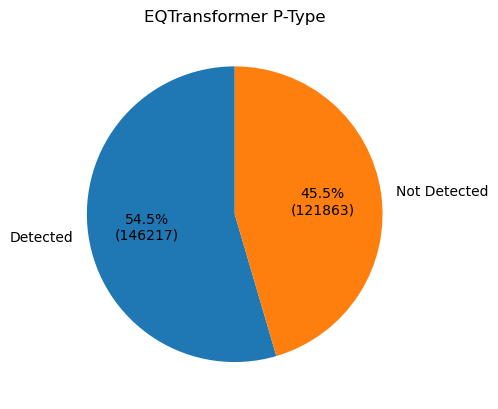

In [96]:
eqt_p = {'Detected':     (msk_p & msk_cat & msk_eqt).sum(),
         'Not Detected': (msk_p & msk_cat & ~msk_eqt).sum()}
print(eqt_p)
sizes = eqt_p.values()
_ = plt.pie(x=sizes, labels=eqt_p.keys(), autopct=lambda pct: func_pie(pct, sizes), startangle=90)
plt.title('EQTransformer P-Type')
plt.savefig('EQTransformer P.png')
# plt.legend( loc = 'right', labels=eqt_p.keys())

{'Detected': 14392, 'Not Detected': 4499}


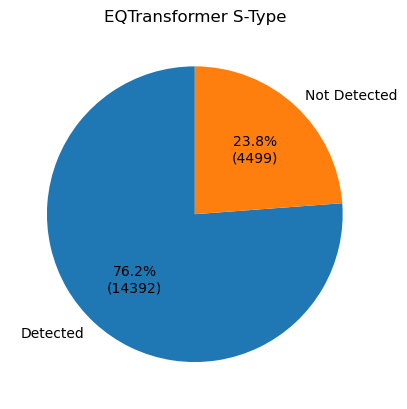

In [97]:
eqt_s = {'Detected':     (msk_s & msk_cat & msk_eqt).sum(),
         'Not Detected': (msk_s & msk_cat & ~msk_eqt).sum()}
print(eqt_s)
sizes = eqt_s.values()

_ = plt.pie(x=eqt_s.values(), labels=eqt_s.keys(), autopct=lambda pct: func_pie(pct, eqt_s.values()), startangle=90)
plt.title('EQTransformer S-Type')
plt.savefig('EQTransformer S.png')


{'Detected': 230131, 'Not Detected': 37949}


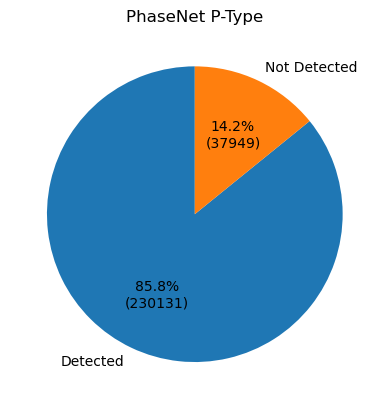

In [98]:
phs_p = {'Detected':     (msk_p & msk_cat & msk_phs).sum(),
         'Not Detected': (msk_p & msk_cat & ~msk_phs).sum()}
print(phs_p)
_ = plt.pie(x=phs_p.values(), labels=phs_p.keys(), autopct=lambda pct: func_pie(pct, phs_p.values()), startangle=90)
plt.title('PhaseNet P-Type')
plt.savefig('PhaseNet P.png')


{'Detected': 12062, 'Not Detected': 6829}


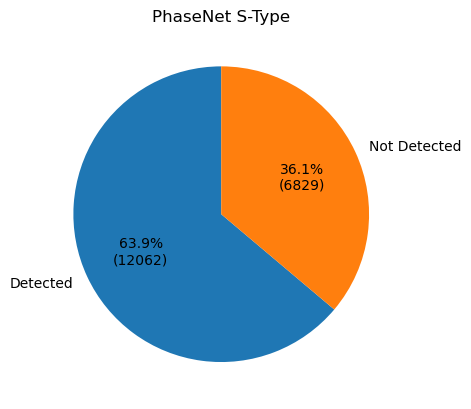

In [99]:
phs_s = {'Detected':     (msk_s & msk_cat & msk_phs).sum(),
         'Not Detected': (msk_s & msk_cat & ~msk_phs).sum()}
print(phs_s)
_ = plt.pie(x=phs_s.values(), labels=phs_s.keys(), autopct=lambda pct: func_pie(pct, phs_s.values()), startangle=90)
plt.title('PhaseNet S-Type')
plt.savefig('PhaseNet S.png')

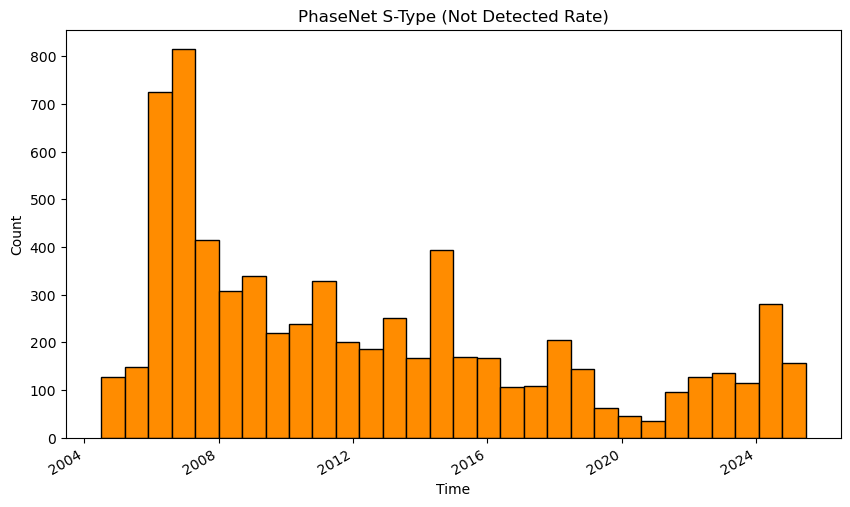

In [92]:
# Example Series of UNIX timestamps
s = df_dl[(msk_s & msk_cat & ~msk_phs)]['catalog_picktime']

# 1. Convert to datetime
dt = pd.to_datetime(s, unit="s")

# 2. Plot histogram
plt.figure(figsize=(10,6))
plt.hist(dt, bins=30, edgecolor="black", color="darkorange")

# 3. Format x-axis
plt.gcf().autofmt_xdate()   # rotates and formats date labels nicely
plt.xlabel("Time")
plt.ylabel("Count")
title = "PhaseNet S-Type (Not Detected Rate)"
plt.title(title)
plt.savefig(f'{title}.png')

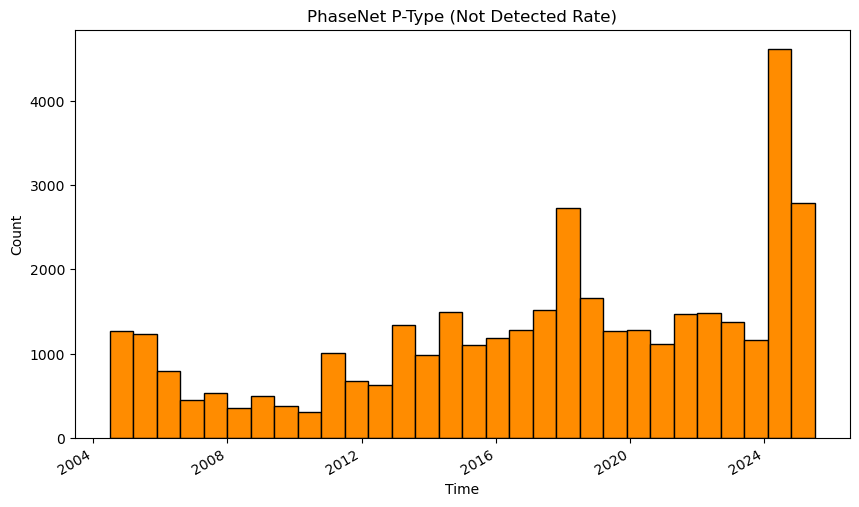

In [91]:
# Example Series of UNIX timestamps
s = df_dl[(msk_p & msk_cat & ~msk_phs)]['catalog_picktime']

# 1. Convert to datetime
dt = pd.to_datetime(s, unit="s")

# 2. Plot histogram
plt.figure(figsize=(10,6))
plt.hist(dt, bins=30, edgecolor="black", color="darkorange")

# 3. Format x-axis
plt.gcf().autofmt_xdate()   # rotates and formats date labels nicely
plt.xlabel("Time")
plt.ylabel("Count")
title = "PhaseNet P-Type (Not Detected Rate)"
plt.title(title)
plt.savefig(f'{title}.png')

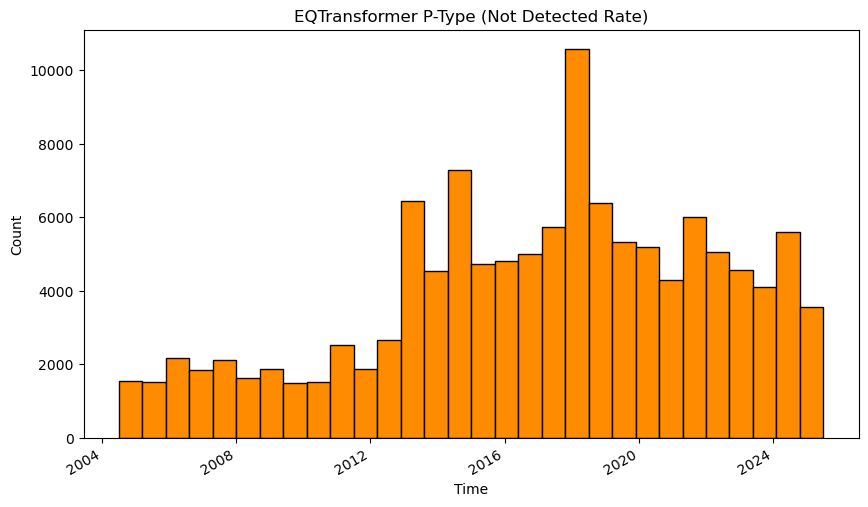

In [90]:
# Example Series of UNIX timestamps
s = df_dl[(msk_p & msk_cat & ~msk_eqt)]['catalog_picktime']

# 1. Convert to datetime
dt = pd.to_datetime(s, unit="s")

# 2. Plot histogram
plt.figure(figsize=(10,6))
plt.hist(dt, bins=30, edgecolor="black", color="darkorange")

# 3. Format x-axis
plt.gcf().autofmt_xdate()   # rotates and formats date labels nicely
plt.xlabel("Time")
plt.ylabel("Count")
title = "EQTransformer P-Type (Not Detected Rate)"
plt.title(title)
plt.savefig(f'{title}.png')

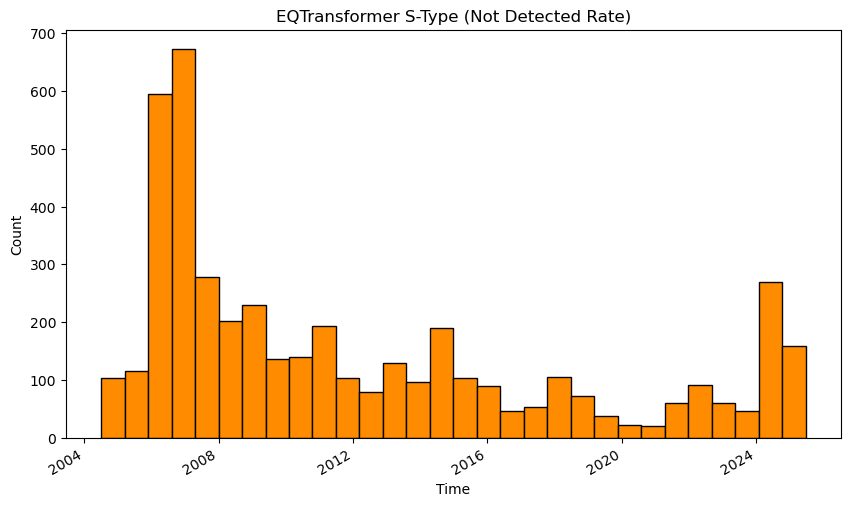

In [89]:
# Example Series of UNIX timestamps
s = df_dl[(msk_s & msk_cat & ~msk_eqt)]['catalog_picktime']

# 1. Convert to datetime
dt = pd.to_datetime(s, unit="s")

# 2. Plot histogram
plt.figure(figsize=(10,6))
plt.hist(dt, bins=30, edgecolor="black", color="darkorange")

# 3. Format x-axis
plt.gcf().autofmt_xdate()   # rotates and formats date labels nicely
plt.xlabel("Time")
plt.ylabel("Count")
title = "EQTransformer S-Type (Not Detected Rate)"
plt.title(title)
plt.savefig(f'{title}.png')